In [58]:
# Imports
import capytaine as cpt
from capytaine.io.legacy import export_hydrostatics
import os
import pygmsh
import gmsh
import xarray as xr
import numpy as np
from matplotlib import pyplot as plt

In [59]:
# Waves and frequencies definitions
# Frequency object
wavefreq    = 1/8 # Hz
f1          = wavefreq
nfreq       = 10

# Define waves object
amplitude   = 0.005 # m
phase       = 0 # degrees
wavedir     = 0 # degrees

rho = 1025

In [60]:
# platform is a rectangle with cg at -0.46 and 1.44 m long, 0.76 m wide
flapThicknessBottom = 0.04
flapThicknessTop    = 0.1
flapCenterDistanceApart = 1.44
flapWidth   = 0.76
flapHeight = 0.58
flapDraft  = 0.59 # 0.53 is based on matching impedance, 0.59 for fully submerged
cgHeightAboveHinge = 0.17
flap1CG     = [-flapCenterDistanceApart/2, 0, -flapDraft+cgHeightAboveHinge] # from water surface/origin
flap2CG     = [flapCenterDistanceApart/2, 0, -flapDraft+cgHeightAboveHinge] # from water surface/origin

platformFrameLength      = 1.44 
platformFrameThickness = 0.05
platformFrameWidth = 1.06
platformFrameTopDepth = 0.53 + 0.1
platformCG      = [0, 0, -0.8]
cutoutWidth         = platformFrameWidth - 2*platformFrameThickness
cutoutLength        = platformFrameLength - 2*platformFrameThickness

fullWidth = 1.63
columnsRadius       = 0.1
columnsDraft        = 0.53 + 0.1 + 0.4
columnsXY           = [flapCenterDistanceApart/2, fullWidth/2-columnsRadius]

daqLength = 0.72
daqWidth = 0.6
daqHeight = 0.2
daqTopDepth = 0.53 + 0.1 + 0.05

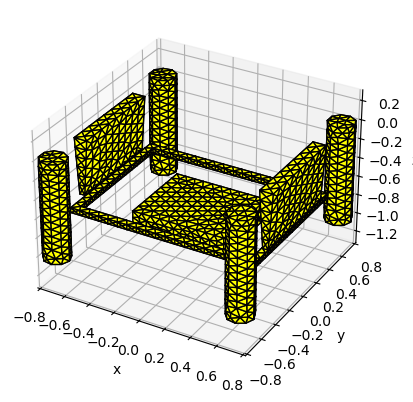

In [ ]:
# Define the meshes
with pygmsh.occ.Geometry() as geom:
    gmsh.option.setNumber('Mesh.MeshSizeFactor', 0.3)
    platform = geom.add_box([-platformFrameLength/2, -platformFrameWidth/2, -platformFrameTopDepth-platformFrameThickness], [platformFrameLength,platformFrameWidth,platformFrameThickness])
    cutout = geom.add_box([-cutoutLength/2, -cutoutWidth/2, -platformFrameTopDepth-platformFrameThickness], [cutoutLength,cutoutWidth,platformFrameThickness])
    cyl1 = geom.add_cylinder([-columnsXY[0], -columnsXY[1], -columnsDraft],[0, 0, columnsDraft+.01], columnsRadius)
    cyl2 = geom.add_cylinder([-columnsXY[0], columnsXY[1], -columnsDraft],[0, 0, columnsDraft+.01], columnsRadius)
    cyl3 = geom.add_cylinder([columnsXY[0], -columnsXY[1], -columnsDraft],[0, 0, columnsDraft+.01], columnsRadius)
    cyl4 = geom.add_cylinder([columnsXY[0], columnsXY[1], -columnsDraft],[0, 0, columnsDraft+.01], columnsRadius)
    DAQ = geom.add_box([-daqLength/2, -daqWidth/2, -daqTopDepth-daqHeight], [daqLength,daqWidth,daqHeight])
    platformFrame = geom.boolean_difference(platform,cutout)
    geom.boolean_union([platformFrame,DAQ,cyl1,cyl2,cyl3,cyl4])
    platformMesh = geom.generate_mesh()

with pygmsh.geo.Geometry() as geom:
    flap1 = geom.add_polygon(
            [[-flapCenterDistanceApart/2 - flapThicknessBottom/2, -flapWidth/2, -flapDraft],
            [-flapCenterDistanceApart/2 + flapThicknessBottom/2, -flapWidth/2, -flapDraft],
            [-flapCenterDistanceApart/2 + flapThicknessTop/2, -flapWidth/2, flapHeight-flapDraft],
            [-flapCenterDistanceApart/2 - flapThicknessTop/2, -flapWidth/2, flapHeight-flapDraft]],mesh_size=0.1)
    geom.extrude(flap1,[0,flapWidth,0])
    flap1Mesh = geom.generate_mesh()

with pygmsh.geo.Geometry() as geom:
    flap2 = geom.add_polygon(
            [[flapCenterDistanceApart/2 - flapThicknessBottom/2, -flapWidth/2, -flapDraft],
            [flapCenterDistanceApart/2 + flapThicknessBottom/2, -flapWidth/2, -flapDraft],
            [flapCenterDistanceApart/2 + flapThicknessTop/2, -flapWidth/2, flapHeight-flapDraft],
            [flapCenterDistanceApart/2 - flapThicknessTop/2, -flapWidth/2, flapHeight-flapDraft]],mesh_size=0.1)
    geom.extrude(flap2,[0,flapWidth,0])
    flap2Mesh = geom.generate_mesh()

# Define the capytaine objects
platform = cpt.FloatingBody(mesh=platformMesh, name=f'platform', center_of_mass=platformCG)
platform.add_all_rigid_body_dofs()
platform.rotation_center = platform.center_of_mass
platform.inertia = platform.compute_rigid_body_inertia(rho=rho)
platform.hydrostatic_stiffness = platform.immersed_part().compute_hydrostatic_stiffness(rho=rho)
platform.compute_hydrostatics()

flap1 = cpt.FloatingBody(mesh=flap1Mesh, name=f'flap1', center_of_mass=flap1CG)
flap1.add_all_rigid_body_dofs()
flap1.rotation_center = flap1.center_of_mass
flap1.inertia = flap1.compute_rigid_body_inertia(rho=rho)
flap1.hydrostatic_stiffness = flap1.immersed_part().compute_hydrostatic_stiffness(rho=rho)
flap1.compute_hydrostatics()

flap2 = cpt.FloatingBody(mesh=flap2Mesh, name=f'flap2', center_of_mass=flap2CG)
flap2.add_all_rigid_body_dofs()
flap2.rotation_center = flap2.center_of_mass
flap2.inertia = flap2.compute_rigid_body_inertia(rho=rho)
flap2.hydrostatic_stiffness = flap2.immersed_part().compute_hydrostatic_stiffness(rho=rho)
flap2.compute_hydrostatics()

foswec_all_fb = platform + flap1 + flap2
#foswec_all_fb.show()
foswec_all_fb.show_matplotlib()



In [62]:
#flap1 = flap1.immersed_part()
#flap1.translate(-np.array(flap1CG))

#cpt.io.mesh_writers.write_GDF('checkWAMIT/flap1.gdf',flap1.mesh.vertices, flap1.mesh.faces, ulen=1)

In [63]:
rho = 1025
g = 9.81

test_matrix = xr.Dataset(coords={
    "omega": np.linspace(f1*2*np.pi, nfreq*f1*2*np.pi, nfreq, True),
    "radiating_dof": list(foswec_all_fb.dofs),
    "wave_direction": [0],
    "water_depth": [2],
    "rho": [rho],
    "g": [g]
    })

solver = cpt.BEMSolver()
write_info = {'hydrostatics': True,'mesh': False,'wavelength': False,'wavenumber': False}
dataset = solver.fill_dataset(test_matrix, foswec_all_fb.immersed_part(), n_jobs=2, **write_info)



Output()

In [64]:
body_coord = dataset.coords["body_name"].values
com = np.vstack([b.center_of_mass for b in [platform, flap1, flap2]])
cob = np.vstack([b.center_of_buoyancy for b in [platform, flap1, flap2]])
volumes = np.array([b.immersed_part().volume for b in [platform, flap1, flap2]], dtype=float)

dataset["center_of_mass"] = xr.DataArray(com, dims=("bod","xyz"), coords={"body": body_coord, "xyz": ["x","y","z"]},attrs={"units": "m"})
dataset["center_of_buoyancy"] = xr.DataArray(cob, dims=("bod","xyz"), coords={"body": body_coord, "xyz": ["x","y","z"]},attrs={"units": "m"})
dataset["volume"] = xr.DataArray(volumes, dims=("bod",), coords={"body": body_coord}, attrs={"units": "m^3"})

input_data_dir = os.getcwd()
output_dir = os.path.join(input_data_dir, '')

dataset['radiating_dof'] = dataset['radiating_dof'].astype(str)
dataset['influenced_dof'] = dataset['influenced_dof'].astype(str)
cpt.io.xarray.separate_complex_values(dataset).to_netcdf(os.path.join(output_dir, 'foswec_jeff_hs.nc'))

cpt.export_dataset(os.path.join(output_dir, 'foswec_jeff_hs_submerged.nc'), dataset)